  Loading Fashion-MNIST …
  Train: (10000, 784)   Test: (2000, 784)
  Classes: [0 1 2 3 4 5 6 7 8 9]



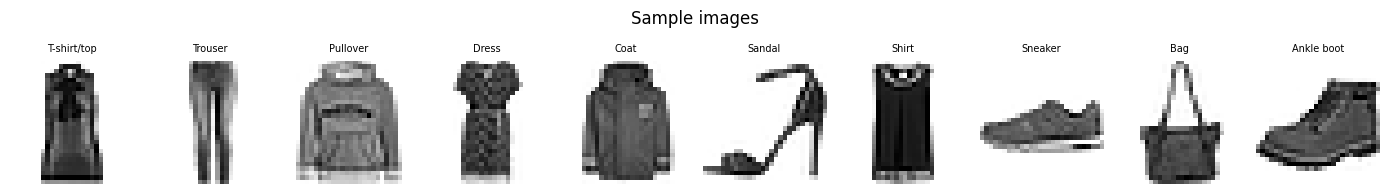

  Saved  01_sample_images.png
  PCA ON  →  100 components

  Model                      Acc      F1      Time
------------------------------------------------------------
  Decision Tree            0.715   0.714      1.5s
  Random Forest            0.829   0.827      1.2s
  MLP                      0.853   0.853      4.1s
  k-NN (k=5)               0.821   0.820      0.2s
  SVM (RBF)                0.869   0.868      1.4s



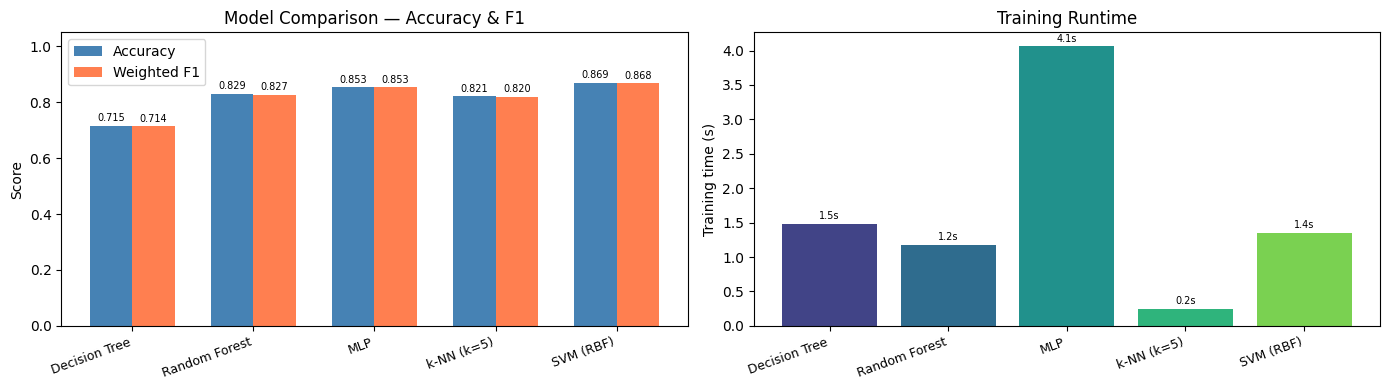

  Saved  02_summary_comparison.png



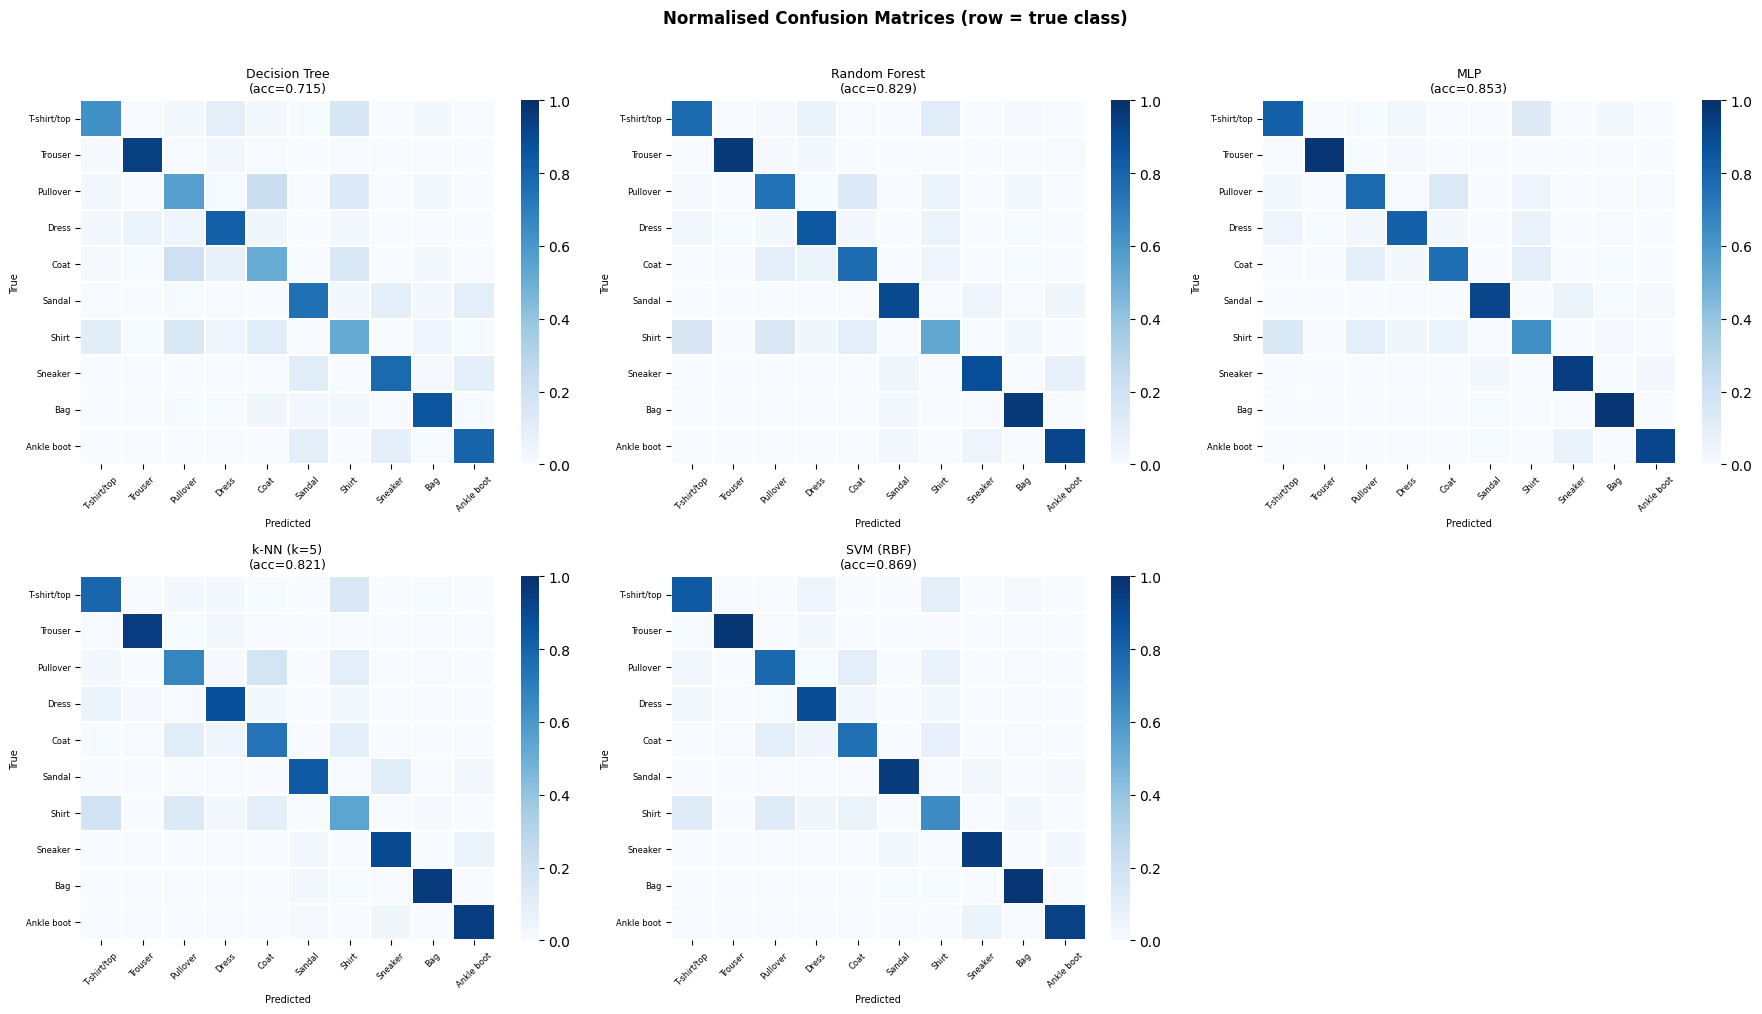

  Saved  03_confusion_matrices.png



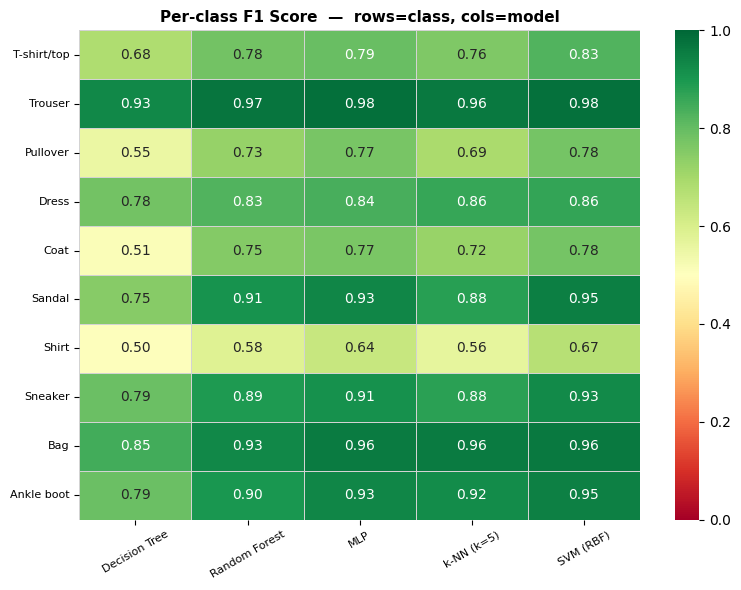

  Saved  04_per_class_f1.png

  Error visualisation for: SVM (RBF)


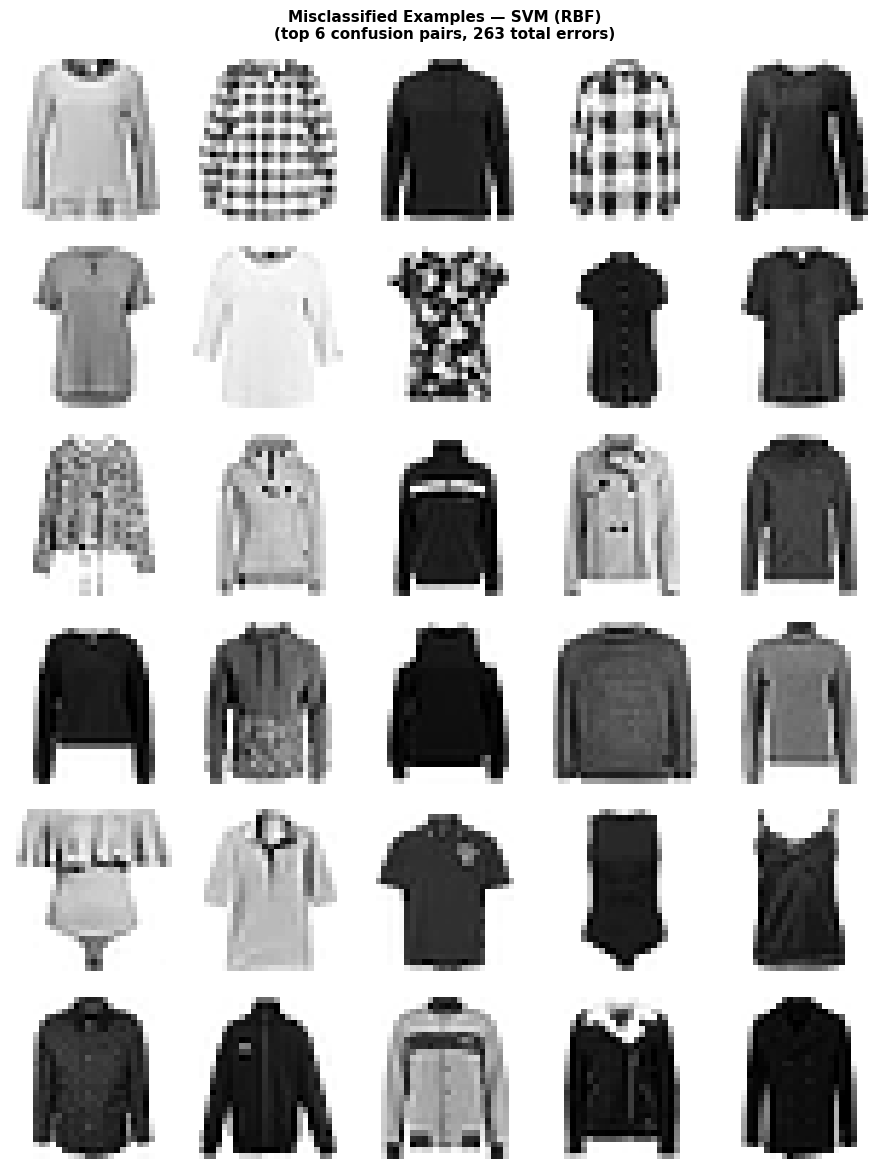

  Saved  05_error_visualisation.png



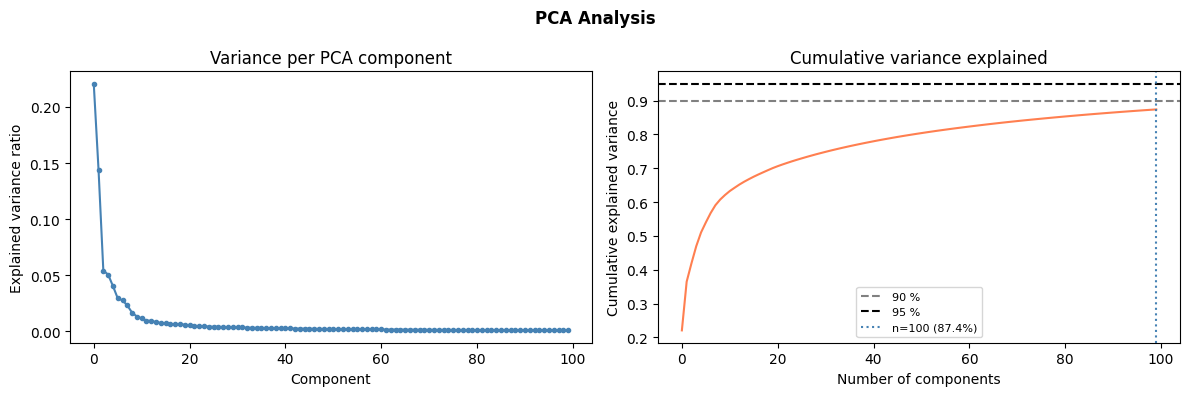

  Saved  06_pca_variance.png

  Detailed Classification Reports

── Decision Tree ─────────────────────────────
              precision    recall  f1-score   support

 T-shirt/top       0.75      0.62      0.68       200
     Trouser       0.92      0.94      0.93       200
    Pullover       0.55      0.56      0.55       200
       Dress       0.74      0.81      0.78       200
        Coat       0.52      0.51      0.51       200
      Sandal       0.74      0.75      0.75       200
       Shirt       0.50      0.52      0.50       200
     Sneaker       0.80      0.78      0.79       200
         Bag       0.84      0.85      0.85       200
  Ankle boot       0.78      0.80      0.79       200

    accuracy                           0.71      2000
   macro avg       0.71      0.71      0.71      2000
weighted avg       0.71      0.71      0.71      2000


── Random Forest ─────────────────────────────
              precision    recall  f1-score   support

 T-shirt/top       0.79   

In [2]:
"""
=============================================================
 Fashion-MNIST Classification  —  In-Class Group Project
=============================================================
Graduate / Advanced Undergraduate Machine Learning
Class: 8:30 – 9:50   |   Lecture ends ~8:40   |   Done by 9:45

Instructions
------------
Work in groups of three.  Go to your whiteboard section before
you open your laptops.  This scaffold handles data loading and
the comparison loop.  Your job is to:

  1. Understand every section and be able to explain any line.
  2. Make deliberate choices where marked  >>>  and justify them.
  3. Run the script (SVM at least once — record the time on the board).
  4. Analyse the three required figures:
       02_summary_comparison.png   —  accuracy / F1 / runtime
       04_per_class_f1.png         —  per-class F1 heatmap (★ richest plot)
       05_error_visualisation.png  —  actual misclassified images
  5. Answer the five reflection questions in your submission doc.
     (06_pca_variance.png and 03_confusion_matrices.png are also
      produced — useful context, but not required in your submission.)

Whiteboard tasks (before typing any answers)
--------------------------------------------
  • Sketch the pipeline and fill in your actual config values
  • Build a hand-written results table: model | accuracy | F1 | time
  • Circle the hardest class on the F1 heatmap and note a hypothesis
  • Sketch your Q5 improvement as a pipeline modification
  • Photograph your whiteboard — it is part of your submission

Quick-start
-----------
    pip install scikit-learn matplotlib seaborn
    python fashion_mnist_project.py
"""

# ── Standard library ──────────────────────────────────────────────────────────
import time
import warnings
warnings.filterwarnings("ignore")

# ── Third-party ───────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC                          # ← comment out if too slow
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)


# ══════════════════════════════════════════════════════════════════════════════
# 0.  CONFIGURATION  —  edit this section
# ══════════════════════════════════════════════════════════════════════════════

# >>> How many training samples to use?
#     Start with 10 000 so the loop finishes in a few minutes.
#     Increase once you understand the code — but watch the SVM runtime.
N_TRAIN = 10_000
N_TEST  =  2_000

# >>> Toggle PCA on / off.  One boolean controls this for ALL models.
#     When ON, set the number of components to retain.
USE_PCA      = True
PCA_N_COMPONENTS = 100    # >>> try 50, 150 — what changes? (Q4)

RANDOM_STATE = 42          # keep fixed so results are reproducible

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal",      "Shirt",   "Sneaker",  "Bag",   "Ankle boot"
]


# ══════════════════════════════════════════════════════════════════════════════
# 1.  DATA LOADING & SPLITTING
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  Loading Fashion-MNIST …")
print("=" * 60)

# fetch_openml caches locally after the first download (~30 MB)
data = fetch_openml("Fashion-MNIST", version=1, as_frame=False, parser="auto")
X, y = data.data, data.target.astype(int)

# Sub-sample so the loop completes in reasonable time
# >>> Why is stratify=y important here?  What would happen without it?
X_sub, _, y_sub, _ = train_test_split(
    X, y, train_size=N_TRAIN + N_TEST,
    stratify=y, random_state=RANDOM_STATE
)

X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size=N_TEST,
    stratify=y_sub, random_state=RANDOM_STATE
)

print(f"  Train: {X_train.shape}   Test: {X_test.shape}")
print(f"  Classes: {np.unique(y_train)}\n")


# ══════════════════════════════════════════════════════════════════════════════
# 2.  VISUALISE A FEW SAMPLES  (always look at your data first!)
# ══════════════════════════════════════════════════════════════════════════════

def plot_samples(X, y, class_names, n=10, title="Sample images"):
    fig, axes = plt.subplots(1, n, figsize=(14, 2))
    fig.suptitle(title, fontsize=12)
    indices = [np.where(y == c)[0][0] for c in range(n)]
    for ax, idx in zip(axes, indices):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray_r")
        ax.set_title(class_names[y[idx]], fontsize=7)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("01_sample_images.png", dpi=120)
    plt.show()
    print("  Saved  01_sample_images.png")

plot_samples(X_train, y_train, CLASS_NAMES)


# ══════════════════════════════════════════════════════════════════════════════
# 3.  PREPROCESSING BLOCK  (scaler + optional PCA)
# ══════════════════════════════════════════════════════════════════════════════

scaler = StandardScaler()

if USE_PCA:
    pca = PCA(n_components=PCA_N_COMPONENTS, random_state=RANDOM_STATE)
    preprocessing = [("scaler", scaler), ("pca", pca)]
    print(f"  PCA ON  →  {PCA_N_COMPONENTS} components")
else:
    preprocessing = [("scaler", scaler)]
    print("  PCA OFF  →  raw 784-d pixels")

print()


# ══════════════════════════════════════════════════════════════════════════════
# 4.  CLASSIFIER DEFINITIONS
#     Five classifiers matching the lecture slides.
#     >>> Add, remove, or tune entries here — each is (display_name, clf_object).
#         Note: Gradient Boosting is excluded to keep runtime manageable.
# ══════════════════════════════════════════════════════════════════════════════

classifiers = [
    ("Decision Tree",
     DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE)),

    ("Random Forest",
     RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)),

    ("MLP",
     MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=30,
                   random_state=RANDOM_STATE)),

    ("k-NN (k=5)",
     KNeighborsClassifier(n_neighbors=5, n_jobs=-1)),

    # >>> SVM is slow — O(n²)–O(n³) in training samples.  Run it at least once,
    #     record the time on your whiteboard, then comment it out if needed. (Q3)
    ("SVM (RBF)",
     SVC(kernel="rbf", C=10, gamma="scale", random_state=RANDOM_STATE)),
]


# ══════════════════════════════════════════════════════════════════════════════
# 5.  TRAINING & EVALUATION LOOP
# ══════════════════════════════════════════════════════════════════════════════

results   = []   # one dict per classifier
pipelines = {}   # keep fitted pipelines for later error analysis

print("=" * 60)
print(f"  {'Model':<22}  {'Acc':>6}  {'F1':>6}  {'Time':>8}")
print("-" * 60)

for name, clf in classifiers:
    pipe = Pipeline(preprocessing + [("clf", clf)])

    t0 = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = pipe.predict(X_test)
    infer_time = time.time() - t0

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="weighted")

    results.append({
        "name":       name,
        "accuracy":   acc,
        "f1":         f1,
        "train_time": train_time,
        "infer_time": infer_time,
        "y_pred":     y_pred,
    })
    pipelines[name] = pipe

    print(f"  {name:<22}  {acc:>6.3f}  {f1:>6.3f}  {train_time:>7.1f}s")

print("=" * 60, "\n")


# ══════════════════════════════════════════════════════════════════════════════
# 6.  SUMMARY BAR CHART  —  accuracy & F1 side-by-side
# ══════════════════════════════════════════════════════════════════════════════

def plot_summary(results):
    names      = [r["name"]     for r in results]
    accuracies = [r["accuracy"] for r in results]
    f1s        = [r["f1"]       for r in results]
    times      = [r["train_time"] for r in results]

    x = np.arange(len(names))
    w = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # -- accuracy / F1 --
    ax = axes[0]
    bars1 = ax.bar(x - w/2, accuracies, w, label="Accuracy", color="steelblue")
    bars2 = ax.bar(x + w/2, f1s,        w, label="Weighted F1", color="coral")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title("Model Comparison — Accuracy & F1")
    ax.legend()
    ax.bar_label(bars1, fmt="%.3f", fontsize=7, padding=2)
    ax.bar_label(bars2, fmt="%.3f", fontsize=7, padding=2)

    # -- runtime --
    ax = axes[1]
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(names)))
    bars = ax.bar(x, times, color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("Training time (s)")
    ax.set_title("Training Runtime")
    ax.bar_label(bars, fmt="%.1fs", fontsize=7, padding=2)

    plt.tight_layout()
    plt.savefig("02_summary_comparison.png", dpi=120)
    plt.show()
    print("  Saved  02_summary_comparison.png\n")

plot_summary(results)


# ══════════════════════════════════════════════════════════════════════════════
# 7.  CONFUSION MATRICES  —  one heatmap per model
# ══════════════════════════════════════════════════════════════════════════════

def plot_confusion_matrices(results, class_names):
    n_models = len(results)
    ncols    = 3
    nrows    = (n_models + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(6 * ncols, 5 * nrows))
    axes = axes.flatten()

    for i, r in enumerate(results):
        cm = confusion_matrix(y_test, r["y_pred"])
        # Normalise by true class  → shows recall per class
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        sns.heatmap(
            cm_norm, annot=False, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[i], vmin=0, vmax=1, linewidths=0.3
        )
        axes[i].set_title(f"{r['name']}\n(acc={r['accuracy']:.3f})", fontsize=9)
        axes[i].set_xlabel("Predicted", fontsize=7)
        axes[i].set_ylabel("True", fontsize=7)
        axes[i].tick_params(axis="x", rotation=45, labelsize=6)
        axes[i].tick_params(axis="y", rotation=0,  labelsize=6)

    # hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Normalised Confusion Matrices (row = true class)", y=1.01,
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("03_confusion_matrices.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("  Saved  03_confusion_matrices.png\n")

plot_confusion_matrices(results, CLASS_NAMES)


# ══════════════════════════════════════════════════════════════════════════════
# 8.  PER-CLASS F1  —  heatmap across all models
#     Rows = class, Columns = model  — great for spotting hard classes
# ══════════════════════════════════════════════════════════════════════════════

def plot_per_class_f1(results, class_names):
    model_names = [r["name"] for r in results]
    f1_matrix   = np.zeros((len(class_names), len(results)))

    for j, r in enumerate(results):
        report = classification_report(
            y_test, r["y_pred"], output_dict=True, zero_division=0
        )
        for i in range(len(class_names)):
            f1_matrix[i, j] = report[str(i)]["f1-score"]

    fig, ax = plt.subplots(figsize=(max(8, len(results) * 1.5), 6))
    sns.heatmap(
        f1_matrix, annot=True, fmt=".2f", cmap="RdYlGn",
        xticklabels=model_names, yticklabels=class_names,
        ax=ax, vmin=0, vmax=1, linewidths=0.5, linecolor="lightgray"
    )
    ax.set_title("Per-class F1 Score  —  rows=class, cols=model",
                 fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)
    plt.tight_layout()
    plt.savefig("04_per_class_f1.png", dpi=120)
    plt.show()
    print("  Saved  04_per_class_f1.png\n")

plot_per_class_f1(results, CLASS_NAMES)


# ══════════════════════════════════════════════════════════════════════════════
# 9.  ERROR VISUALISATION
#     Pick the best-performing model and show images it got wrong,
#     grouped by (true_label → predicted_label).
#     >>> Try changing FOCUS_MODEL to compare error types across classifiers.
# ══════════════════════════════════════════════════════════════════════════════

# >>> Change this to any model name from the classifiers list.
#     Compare the best model's errors against the Decision Tree — see Q2.
FOCUS_MODEL = max(results, key=lambda r: r["accuracy"])["name"]
print(f"  Error visualisation for: {FOCUS_MODEL}")

def plot_errors(result, X_test, y_test, class_names,
                max_pairs=6, n_per_pair=5):
    """
    Show confused image pairs:  (true_class → predicted_class).
    Each row is one (true → pred) confusion pair;
    each column is a misclassified example.
    """
    y_pred  = result["y_pred"]
    errors  = np.where(y_pred != y_test)[0]

    # find the most frequent confusion pairs
    pair_counts = {}
    for idx in errors:
        pair = (y_test[idx], y_pred[idx])
        pair_counts[pair] = pair_counts.get(pair, 0) + 1

    top_pairs = sorted(pair_counts, key=pair_counts.get, reverse=True)[:max_pairs]

    fig, axes = plt.subplots(
        len(top_pairs), n_per_pair,
        figsize=(n_per_pair * 1.8, len(top_pairs) * 2.0)
    )
    if len(top_pairs) == 1:
        axes = axes[np.newaxis, :]

    for row, (true_c, pred_c) in enumerate(top_pairs):
        examples = [i for i in errors
                    if y_test[i] == true_c and y_pred[i] == pred_c][:n_per_pair]
        row_label = f"True: {class_names[true_c]}\n→ {class_names[pred_c]}"
        axes[row, 0].set_ylabel(row_label, fontsize=8, rotation=0,
                                 labelpad=80, va="center")
        for col in range(n_per_pair):
            ax = axes[row, col]
            if col < len(examples):
                ax.imshow(X_test[examples[col]].reshape(28, 28), cmap="gray_r")
            ax.axis("off")

    fig.suptitle(
        f"Misclassified Examples — {result['name']}\n"
        f"(top {len(top_pairs)} confusion pairs, {len(errors)} total errors)",
        fontsize=11, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig("05_error_visualisation.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("  Saved  05_error_visualisation.png\n")

focus_result = next(r for r in results if r["name"] == FOCUS_MODEL)
plot_errors(focus_result, X_test, y_test, CLASS_NAMES)


# ══════════════════════════════════════════════════════════════════════════════
# 10.  PCA VARIANCE EXPLAINED  (only shown when PCA is active)
# ══════════════════════════════════════════════════════════════════════════════

if USE_PCA:
    # Retrieve the fitted PCA step from any pipeline
    pca_fitted = list(pipelines.values())[0].named_steps["pca"]
    cum_var    = np.cumsum(pca_fitted.explained_variance_ratio_)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(pca_fitted.explained_variance_ratio_, marker="o", ms=3,
                 color="steelblue")
    axes[0].set_xlabel("Component")
    axes[0].set_ylabel("Explained variance ratio")
    axes[0].set_title("Variance per PCA component")

    axes[1].plot(cum_var, color="coral")
    axes[1].axhline(0.90, ls="--", color="gray", label="90 %")
    axes[1].axhline(0.95, ls="--", color="black", label="95 %")
    axes[1].axvline(PCA_N_COMPONENTS - 1, ls=":", color="steelblue",
                    label=f"n={PCA_N_COMPONENTS} ({cum_var[PCA_N_COMPONENTS-1]:.1%})")
    axes[1].set_xlabel("Number of components")
    axes[1].set_ylabel("Cumulative explained variance")
    axes[1].set_title("Cumulative variance explained")
    axes[1].legend(fontsize=8)

    plt.suptitle("PCA Analysis", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("06_pca_variance.png", dpi=120)
    plt.show()
    print("  Saved  06_pca_variance.png\n")


# ══════════════════════════════════════════════════════════════════════════════
# 11.  FULL CLASSIFICATION REPORT  (text)
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  Detailed Classification Reports")
print("=" * 60)

for r in results:
    print(f"\n── {r['name']} ─────────────────────────────")
    print(classification_report(
        y_test, r["y_pred"],
        target_names=CLASS_NAMES, zero_division=0
    ))


# ══════════════════════════════════════════════════════════════════════════════
# ┌──────────────────────────────────────────────────────────────────────────┐
# │  REFLECTION QUESTIONS  —  answer these in your submission document       │
# │  Every answer must cite specific evidence from your figures.             │
# │  Your whiteboard photo is also part of your submission.                  │
# │                                                                          │
# │  Q1. Which model gives the best accuracy-to-runtime ratio?               │
# │      Which would you deploy to classify millions of garments per day,    │
# │      and which would you rule out first?  Justify with numbers from      │
# │      02_summary_comparison.png.                                          │
# │                                                                          │
# │  Q2. Using 04_per_class_f1.png, identify the clothing category with      │
# │      the lowest F1 across the majority of models.  Then use              │
# │      05_error_visualisation.png to explain why.  Can you tell the        │
# │      confused categories apart by eye?  What does this say about the     │
# │      limits of any pixel-based classifier on this problem?               │
# │                                                                          │
# │  Q3. Describe what happened to the SVM's training time relative to       │
# │      the other models.  SVM scales ~O(n²)–O(n³) with training samples.  │
# │      What would happen if you doubled N_TRAIN?  What does this mean      │
# │      for using SVMs in practice?                                         │
# │                                                                          │
# │  Q4. Toggle USE_PCA = False and re-run at least one classifier           │
# │      (skip the SVM).  What changed in accuracy and runtime?              │
# │      Which model type benefited most from PCA, and which was least       │
# │      affected?  Explain why in each case.                                │
# │                                                                          │
# │  Q5. Propose one concrete improvement to the pipeline — a different      │
# │      model, preprocessing step, ensemble, or data augmentation           │
# │      strategy.  Sketch where your change fits in the pipeline on         │
# │      your whiteboard, then describe it here.  Your proposal must be      │
# │      tied to a specific weakness observed in your figures.               │
# └──────────────────────────────────────────────────────────────────────────┘
# ══════════════════════════════════════════════════════════════════════════════

print("\nDone!  Check the saved PNG files for your report.\n")
